In [2]:
# Testing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from PIL import Image

print("✅ All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

✅ All libraries imported successfully!
PyTorch version: 2.9.1+cpu
CUDA available: False


In [1]:
# ==========================================
# DATA EXPLORATION
# ==========================================

import os
import matplotlib.pyplot as plt
from PIL import Image
import random

# Dataset path
dataset_path = r"C:\Users\DELL\OneDrive\Desktop\plantvillage dataset\color"

# Get all classes
classes = sorted(os.listdir(dataset_path))

print("=" * 60)
print("DATASET EXPLORATION")
print("=" * 60)
print(f"\n✅ Total Disease Classes: {len(classes)}\n")

# Count images per class
class_counts = {}
for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    num_images = len(os.listdir(cls_path))
    class_counts[cls] = num_images

# Show first 15 classes with counts
print("📊 Sample Classes with Image Counts:\n")
for i, (cls, count) in enumerate(list(class_counts.items())[:15], 1):
    print(f"{i:2d}. {cls:50s} → {count:4d} images")

print(f"\n📈 Total Images in Dataset: {sum(class_counts.values())}")
print("=" * 60)

DATASET EXPLORATION

✅ Total Disease Classes: 38

📊 Sample Classes with Image Counts:

 1. Apple___Apple_scab                                 →  630 images
 2. Apple___Black_rot                                  →  621 images
 3. Apple___Cedar_apple_rust                           →  275 images
 4. Apple___healthy                                    → 1645 images
 5. Blueberry___healthy                                → 1502 images
 6. Cherry_(including_sour)___Powdery_mildew           → 1052 images
 7. Cherry_(including_sour)___healthy                  →  854 images
 8. Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot →  513 images
 9. Corn_(maize)___Common_rust_                        → 1192 images
10. Corn_(maize)___Northern_Leaf_Blight                →  985 images
11. Corn_(maize)___healthy                             → 1162 images
12. Grape___Black_rot                                  → 1180 images
13. Grape___Esca_(Black_Measles)                       → 1383 images
14. Grape___Leaf

✅ Sample images saved as 'sample_images.png'


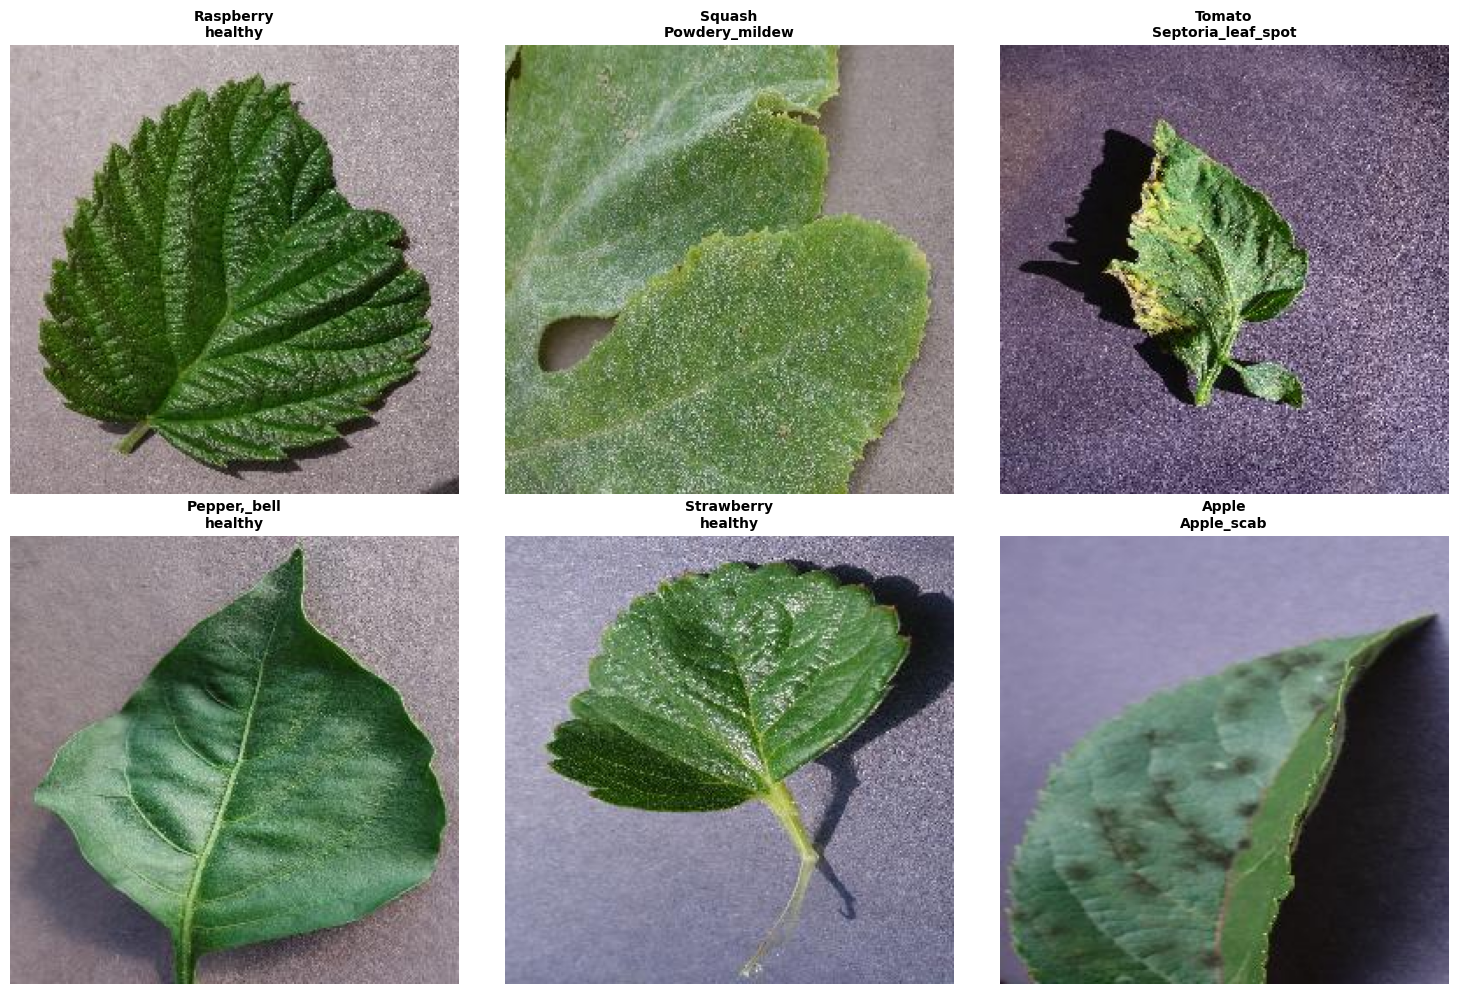

In [2]:
# ==========================================
# VISUALIZE SAMPLE IMAGES
# ==========================================

# Select 6 random classes
sample_classes = random.sample(classes, 6)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, cls in enumerate(sample_classes):
    cls_path = os.path.join(dataset_path, cls)
    # Pick random image from class
    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)
    
    # Load and display
    img = Image.open(img_path)
    axes[idx].imshow(img)
    axes[idx].set_title(cls.replace('___', '\n'), fontsize=10, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
print("✅ Sample images saved as 'sample_images.png'")
plt.show()

In [ ]:
# ==========================================
# DATA PREPROCESSING
# ==========================================

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
import numpy as np

print("=" * 60)
print("DATA PREPROCESSING")
print("=" * 60)

# Step 1: Create list of all image paths and labels
all_images = []
all_labels = []

for idx, cls in enumerate(classes):
    cls_path = os.path.join(dataset_path, cls)
    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        all_images.append(img_path)
        all_labels.append(idx)  # idx is class number

print(f"\n✅ Total images collected: {len(all_images)}")
print(f"✅ Total unique labels: {len(set(all_labels))}")

# Step 2: Train-Test Split (80% train, 20% test)
train_images, test_images, train_labels, test_labels = train_test_split(
    all_images, all_labels, 
    test_size=0.2, 
    random_state=42,
    stratify=all_labels  # Equal distribution
)

print(f"\n📊 Training images: {len(train_images)}")
print(f"📊 Testing images: {len(test_images)}")
print(f"📊 Split ratio: {len(train_images)/len(all_images)*100:.1f}% train, {len(test_images)/len(all_images)*100:.1f}% test")

print("\n✅ Data split complete!")
print("=" * 60)